In [28]:
import numpy as np
import pandas as pd
from numpy import nan
from sklearn.preprocessing import  StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from nltk.stem import SnowballStemmer
from sklearn import linear_model, datasets


import nltk
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
dev = pd.read_csv("winter_project_2026/development.csv")
eva= pd.read_csv("winter_project_2026/evaluation.csv")

In [4]:
display(dev)
print(dev.columns)

columns = dev.columns
for col in columns:
    print(f"{col} :{dev.iloc[0][col]}")

,Id,source,title,article,page_rank,timestamp,label
0,0,AllAfrica.com,OPEC Boosts Nigeria&#39;s Oil Revenue By .82m Bpd,THE Organisation of Petroleum Exporting Countr...,5,2004-09-16 22:39:53,5
1,1,Xinhua,Yearender: Mideast peace roadmap reaches dead-...,Looking back at the major events that took pla...,5,2004-12-17 19:01:14,0
2,2,Yahoo,Battleground Dispatches for Oct. 5 \\n (CQP...,CQPolitics.com - Here are today's Battleground...,5,2006-10-05 18:42:29,0
3,3,BBC,Air best to resuscitate newborns,Air rather than oxygen should be used to resus...,5,0000-00-00 00:00:00,0
4,4,Yahoo,High tech German train crash kills at least on...,"<p><a href=""http://us.rd.yahoo.com/dailynews/r...",5,2006-09-22 17:28:57,0
...,...,...,...,...,...,...,...
79992,79992,Yahoo,Italy's embattled Prodi faces vote of confiden...,"<p><a href=""http://us.rd.yahoo.com/dailynews/r...",5,2008-01-23 11:39:35,0
79993,79993,All-Baseball.com,"Ding Dong, the Deal is Dead","As yesterday began, there was widespread antic...",5,0000-00-00 00:00:00,4
79994,79994,Yahoo,Two bombs discovered in Sardinia after Berlusc...,AFP - Police discovered two bombs near the Sar...,5,0000-00-00 00:00:00,0
79995,79995,Voice,Red Cross Report Alleges US Detainee Abuse at ...,A report by the International Committee of the...,5,0000-00-00 00:00:00,3


Index(['Id', 'source', 'title', 'article', 'page_rank', 'timestamp', 'label'], dtype='object')
Id :0
source :AllAfrica.com
title :OPEC Boosts Nigeria&#39;s Oil Revenue By .82m Bpd
article :THE Organisation of Petroleum Exporting Countries (OPEC) is hiking its official output by one million barrels per day effective November with Nigeria getting 82,000 barrels per day or 8.2 per cent of the new quota.
page_rank :5
timestamp :2004-09-16 22:39:53
label :5


In [5]:
print(f"shape dev:{dev.shape}")
print(f"shape eva:{eva.shape}")
for col in columns:
    print(f"unique {col}: {len(dev[col].unique())}")

shape dev:(79997, 7)
shape eva:(20000, 6)
unique Id: 79997
unique source: 1359
unique title: 75784
unique article: 74394
unique page_rank: 4
unique timestamp: 52183
unique label: 7


In [6]:
#pd.isna(dev).sum()
rows = dev.loc[dev.duplicated(subset=['article', 'title'])]
print(dev.duplicated(subset=['article']).sum())
print(dev.duplicated(subset=['title']).sum())
print(dev.duplicated(subset=['title','article']).sum())
duplicated = dev.loc[dev.duplicated(subset=['title','article'])]
#print(dev.duplicated(subset=['timestamp']).sum())
mask = dev['article'].isin(duplicated['article'])
to_drop = dev[mask]
dev.drop(to_drop["Id"], inplace=True)
dev.drop("Id", inplace=True, axis=1)
dev.dropna(inplace=True)

5603
4213
2954


In [72]:
dev

,source,title,article,page_rank,timestamp,label
0,AllAfrica.com,OPEC Boosts Nigeria&#39;s Oil Revenue By .82m Bpd,THE Organisation of Petroleum Exporting Countr...,5,2004-09-16 22:39:53,5
1,Xinhua,Yearender: Mideast peace roadmap reaches dead-...,Looking back at the major events that took pla...,5,2004-12-17 19:01:14,0
2,Yahoo,Battleground Dispatches for Oct. 5 \\n (CQP...,CQPolitics.com - Here are today's Battleground...,5,2006-10-05 18:42:29,0
3,BBC,Air best to resuscitate newborns,Air rather than oxygen should be used to resus...,5,0000-00-00 00:00:00,0
4,Yahoo,High tech German train crash kills at least on...,"<p><a href=""http://us.rd.yahoo.com/dailynews/r...",5,2006-09-22 17:28:57,0
...,...,...,...,...,...,...
79991,RedNova,LEDs Move Into Home Lighting Market,"By MARK JEWELL EVERETT, Mass. - Joey Nicotera...",4,2007-06-25 07:08:21,2
79992,Yahoo,Italy's embattled Prodi faces vote of confiden...,"<p><a href=""http://us.rd.yahoo.com/dailynews/r...",5,2008-01-23 11:39:35,0
79994,Yahoo,Two bombs discovered in Sardinia after Berlusc...,AFP - Police discovered two bombs near the Sar...,5,0000-00-00 00:00:00,0
79995,Voice,Red Cross Report Alleges US Detainee Abuse at ...,A report by the International Committee of the...,5,0000-00-00 00:00:00,3


In [7]:
stemmer = SnowballStemmer("english")

# 3. La funzione Tokenizer da passare al Vectorizer
def stemmed_tokenizer(text):
    # a. Tokenizza (spezza la frase in parole)
    try:
        tokens = nltk.word_tokenize(text)
    except LookupError:
        # Fallback di sicurezza se punkt fallisce ancora
        tokens = text.split()
    
    # b. Filtra caratteri non alfabetici e applica lo stemmer
    # isalpha() rimuove numeri e punteggiatura
    stems = [stemmer.stem(t) for t in tokens if t.isalpha()]
    
    return stems

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

art = dev['article']
title = dev['title']
cum = title + art
#vectorizer = TfidfVectorizer(stop_words='english',
#                             max_features=25000, 
#                             max_df=0.6,
#                             min_df=100)
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    tokenizer=stemmed_tokenizer,
    ngram_range=(1, 2),
    max_df=0.7,
    min_df=5)

X_art = vectorizer.fit_transform(art)
X_title = vectorizer.fit_transform(title)
X_cum = vectorizer.fit_transform(cum)


/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'there

In [9]:
dev['title'].describe()
dev['article'].describe()

count                                                 72585
unique                                                71864
top       On <a href='http://www.newsisfree.com/sources/...
freq                                                    156
Name: article, dtype: object

In [10]:
df_art = pd.DataFrame(X_art.toarray())
df_title = pd.DataFrame(X_title.toarray())
df_cum = pd.DataFrame(X_cum.toarray())

In [11]:
scaler = StandardScaler()

df_art = scaler.fit_transform(df_art)
df_title = scaler.fit_transform(df_title)
df_cum = scaler.fit_transform(df_cum)


In [78]:
#print(df_art.std())
#print(df_title.std())
#print(df_cum.std())

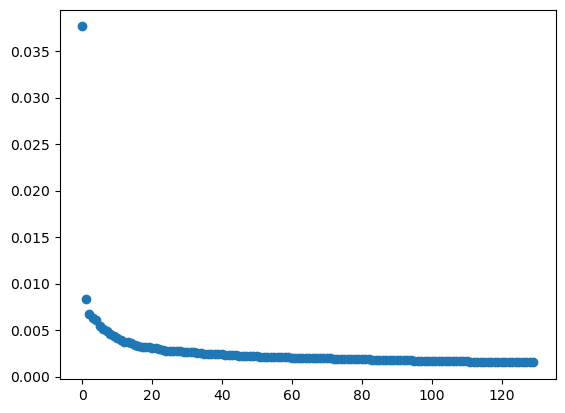

In [12]:
pca = PCA(n_components=130)
X_projection = pca.fit(X_art)
plt.plot(pca.explained_variance_ratio_, marker='o', linestyle='')

In [13]:
def rSVD(X, k, p=10, q=2):
    # X m,n
    # Om n, k+p
    # Y m, k+p 
    m, n = X.shape
    Omega = np.random.normal(size=(n, k + p)) # P = oversampling, increase drastically the aìprobability of extracting usefull data
    Y = X @ Omega
    for _ in range(q):   #POWER ITERATIONS, increase big eigenvals, decrease small eigenvals
        Y = X @ (X.T @ Y)
    Q, _ = np.linalg.qr(Y)
    # Q m, k+p
    B = Q.T @ X   # B is the projection of X in the smaller space ->  dim :(k + p ), n
    # B k+p, n
    U_hat, Sigma, Vt = np.linalg.svd(B, full_matrices=False)
    # Sigma k+p, k+p
    # U_hat k+p, k+p
    # Vt k+p, n
    U = Q @ U_hat # Back to the bigger space
    # U m, k+p
    return U[:, :k], Sigma[:k], Vt[:k, :]       #We return without oversampling col/rows  
    # U m, k
    # Sigma k, k
    # Vt k, n

In [14]:
U_art, Sigma_art, Vt_art = rSVD(df_art, 50)

In [15]:
U_title, Sigma_title, Vt_title = rSVD(df_title, 50)

In [16]:
df_title = pd.DataFrame(U_title, index=dev.index)
df_art = pd.DataFrame(U_art, index=dev.index)
print(df_art.shape , df_title.shape, dev.shape)

df = pd.concat([dev, df_title, df_art], axis=1)
print(len(df['source'].unique()))

(72585, 50) (72585, 50) (72585, 6)
1337


In [17]:
df.head()
diff = df['source'].unique()
l=[]
for item in diff:
    l.append(df['source'].value_counts()[item])

In [18]:
df.sort_values('source')[['label','source']]

,label,source
34369,4,123Bharath.com
20400,4,123Bharath.com
64068,6,123Bharath.com
848,5,123Bharath.com
77405,5,123Bharath.com
...,...,...
9157,0,swissinfo
32164,3,swissinfo
3941,0,swissinfo
50945,5,top40-charts.com


In [19]:
df.groupby(['source']).count().sort_values('source')

,title,article,page_rank,timestamp,label,0,1,2,3,4,...,40,41,42,43,44,45,46,47,48,49
source,,,,,,,,,,,,,,,,,,,,,
123Bharath.com,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
2TheAdvocate,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
365Gay.com,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
4TheGame,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4ni.co.uk,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
socalTech.com,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
sportal.com.au,22,22,22,22,22,22,22,22,22,22,...,22,22,22,22,22,22,22,22,22,22
sportinglife.com,66,66,66,66,66,66,66,66,66,66,...,66,66,66,66,66,66,66,66,66,66


In [20]:
df.drop(['article', 'title', 'timestamp', 'source'], inplace=True, axis=1)

In [21]:
df.head()
y = df['label']
df.drop('label', inplace=True, axis=1)

In [22]:
y

0        5
1        0
2        0
3        0
4        0
        ..
79991    2
79992    0
79994    0
79995    3
79996    0
Name: label, Length: 72585, dtype: int64

In [23]:
cols = np.linspace(1,101,101)
print(cols)



# Renaming the 'name' column to 'full_name' by index
column_index_to_rename = 1  # Index of the 'name' column
new_column_name = 'full_name'

# Renaming the column using the 'rename' method

# Displaying the DataFrame after renaming
i=0
for col in df.columns:
    df.rename(columns={df.columns[i]: i}, inplace=True)
    i +=1

print(df)

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101.]
       100       100       100       100       100       100       100  \
0        5  0.003033 -0.002335 -0.008314 -0.000302  0.006076  0.008967   
1        5  0.000199  0.001321  0.002038  0.001469  0.001017  0.000022   
2        5  0.000039 -0.000132 -0.000164  0.000004  0.000040 -0.000134   
3        5 -0.000169  0.000418  0.001385 -0.001337 -0.001494 -0.000927   
4        5  0.000759  0.000157  0.001244 -0.001128  0.003026  0.002871   
...    ...       ...       ...       ...  

In [24]:

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=RANDOM_SEED)

In [25]:
std = StandardScaler()


X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

In [118]:

clf = RandomForestClassifier(
    n_estimators=100, 
    max_features="sqrt", 
    max_depth=6, 
    max_leaf_nodes=6, 
    random_state=RANDOM_SEED
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

KeyboardInterrupt: 

In [94]:
a = pred==y_test

In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

KeyboardInterrupt: 

In [26]:
model_grid = RandomForestClassifier(max_depth=15,
                                    max_features="log2",
                                    max_leaf_nodes=3,
                                    n_estimators=50,
                                    n_jobs=-1)    
model_grid.fit(X_train, y_train)
y_pred_grid = clf.predict(X_test)
print(classification_report(y_pred_grid, y_test))

NameError: name 'clf' is not defined

In [ ]:
C = np.logspace(0, 2, num=5) #LUCIO
C = np.logspace(2, 4, num=5) #LEO
penalty = ['l1', 'l2']
solver = ['liblinear', 'saga']

hyperparameters = dict(C=C, penalty=penalty, solver=solver)
logistic = linear_model.LogisticRegression()
gridsearch = GridSearchCV(logistic, hyperparameters, n_jobs=-1)
best_model = gridsearch.fit(X_train, y_train)
print(best_model.best_estimator_)

/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classifica

KeyboardInterrupt: 

In [ ]:
clf = LogisticRegression(random_state=RANDOM_SEED).fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)
print(classification_report(y_pred, y_test))